In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

sns.set_context("talk")

%matplotlib inline

In [6]:
def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [4]:
species_map={1:"Si",2:"O"}

df_hist_list=list()
data_dict={"../results/lammps/annealing/2nm/vashishta/results/pdh_npt_heating_5000K/":("Initial","Vashishta",0) 
          ,"../results/lammps/annealing/2nm/vashishta/results/pdh_nvt_equilibration_300K/": ("Final","Vashishta",0)
          ,"../results/lammps/annealing/2nm/reaxff2023/results/pdh_npt_heating_5000K/":("Initial","Reaxff2023",0.5 )
          ,"../results/lammps/annealing/2nm/reaxff2023/results/pdh_nvt_equilibration_300K/": ("Final","Reaxff2023",0.5)
          }

df_hist_list=list()       
for basepath, (State,force_field,shift) in data_dict.items():
    for filename in os.listdir(basepath):
        if not "hist" in filename:
            continue
        filename_split=filename.replace(".csv","").split("_")
        sp_1=int(filename_split[1])
        sp_2=int(filename_split[2])
        df_tmp=pd.read_csv(os.path.join(basepath,filename),skiprows=1,skipfooter=1, engine='python',names=["Separation (nm)","count"])
        df_tmp["Species"]="%s-%s"%(species_map[sp_1],species_map[sp_2]) 
        df_tmp["norm"]=0.5*(df_tmp["count"]/df_tmp["count"].max())+shift
        df_tmp["State"]=State
        df_tmp["Force Filed"]=force_field
        
        df_hist_list.append(df_tmp)
df_hist=pd.concat(df_hist_list,ignore_index=True)
df_hist

,Separation (nm),count,Species,norm,State,Force Filed
0,0.014238,0,Si-Si,0.000000,Initial,Vashishta
1,0.022713,0,Si-Si,0.000000,Initial,Vashishta
2,0.031188,0,Si-Si,0.000000,Initial,Vashishta
3,0.039663,0,Si-Si,0.000000,Initial,Vashishta
4,0.048139,0,Si-Si,0.000000,Initial,Vashishta
...,...,...,...,...,...,...
11995,8.447140,7,O-O,0.500048,Final,Reaxff2023
11996,8.455620,9,O-O,0.500062,Final,Reaxff2023
11997,8.464090,2,O-O,0.500014,Final,Reaxff2023
11998,8.472570,9,O-O,0.500062,Final,Reaxff2023


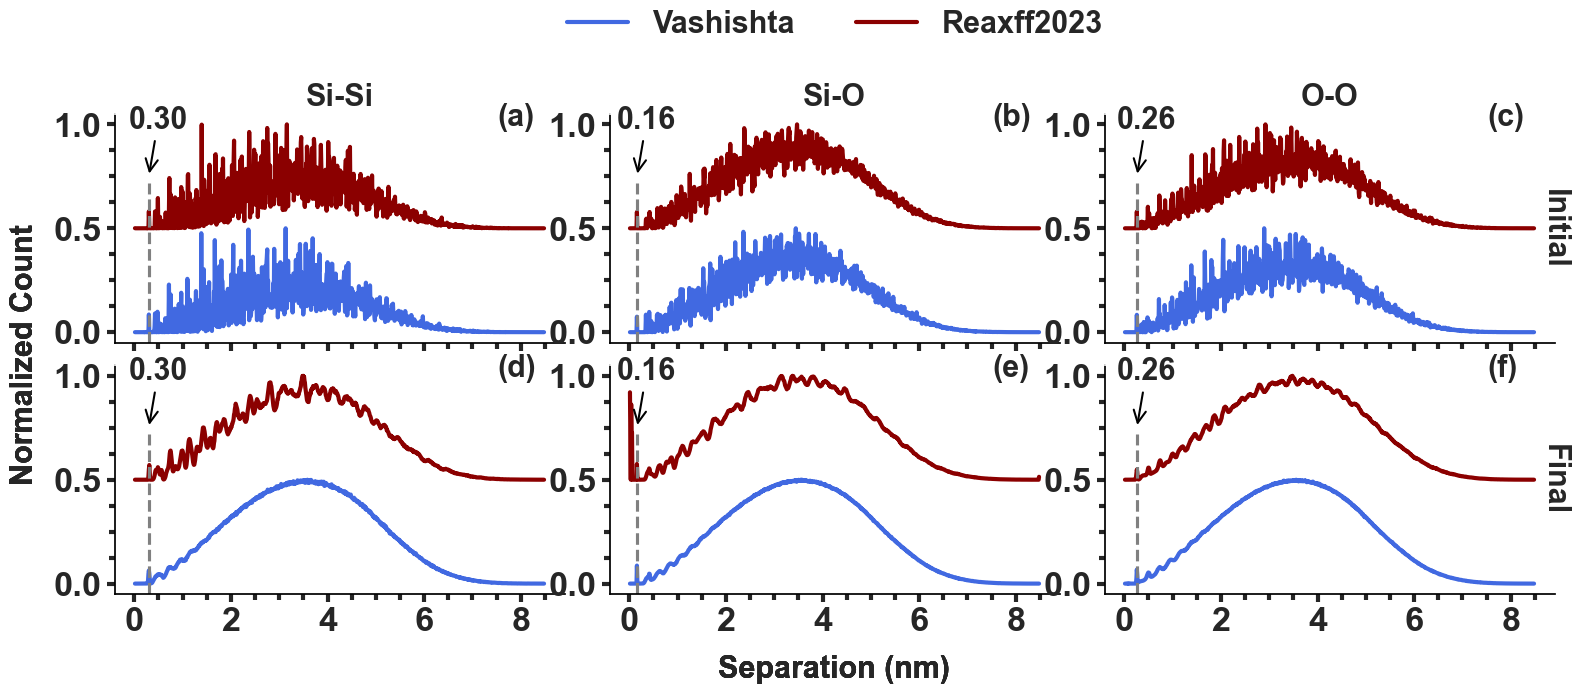

In [24]:
plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")  

state_list=df_hist["State"].unique()
species_list=df_hist["Species"].unique()

len_nrows=len(state_list)
len_ncols=len(species_list)
fig, axs = plt.subplots(nrows=len_nrows,ncols=len_ncols,figsize=(6*len_ncols,3*len_nrows))
sns.set_context("talk")

labx=0.85
laby=0.95

separation_map={"Si-Si":0.3,"O-O":0.26,"Si-O":0.16}

index=["(%s)"%x for x in list("abcdefghijkl")]
df_list=list()
for j, species in enumerate(species_list):
    for i, state in enumerate(state_list):
        ax=axs[i,j]
        ax.text(labx, laby, index[j+len_ncols*i],weight='bold' ,transform=ax.transAxes,fontsize=22)
        df_tmp=df_hist.query(" State == '%s'  and  Species == '%s'  "%(state,species))
        legend=(j==len_ncols-1 and i==0)
        sns.lineplot(data=df_tmp
                     ,x="Separation (nm)"
                     ,y="norm"
                     ,ax=ax
                     ,lw=3
                     ,hue="Force Filed"
                     ,palette=["royalblue","darkred"]
                     ,legend=legend
                    )
        if legend:
            sns.move_legend(ax,'lower center'
                                ,bbox_to_anchor=(.5,1)
                                ,ncol=2
                                ,bbox_transform=fig.transFigure
                                ,title=""
                                ,frameon =False
                                ,borderpad =0
                                ,fontsize=22
                               )

        if i*j==0:
            ax.text(0.5, -0.05, 'Separation (nm)' ,transform=fig.transFigure,ha="center",va="bottom",fontsize=22)
            ax.text(0.05, 0.5, 'Normalized Count' ,transform=fig.transFigure,ha="center",va="center",rotation="vertical",fontsize=22)
        if j == len(species_list)-1:
            ax.text(1, 0.5, state ,transform=ax.transAxes,ha="center",va="center",rotation=-90,fontsize=22,fontweight='bold')

        apply_ax_format(ax)

        if i != len(state_list)-1:
            ax.set_xticklabels([])
#        if i+j != 0:
#            ax.set_yticklabels([])

        if i==0:
            ax.set_title(species,fontweight='bold',fontsize=22)

        ax.annotate("%.2f"%(separation_map[species]), xy=(separation_map[species], 0.75), xytext=(separation_map[species]+0.2, 0.95), arrowprops=dict(arrowstyle="->",color="black"),ha='center',va='bottom',fontweight='bold',fontsize=22)
        ax.axvline(x=separation_map[species],ymin=0,ymax=0.7,c='gray',ls='--')



            
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.1, 
                    hspace=0.1)
plt.savefig("../figures/figA1.pdf", pad_inches=0.2,bbox_inches="tight")

In [4]:
df_hist.query("norm > 0.025").groupby(["State","Species"])["Separation (nm)"].min().unstack()

Species,O-O,Si-O,Si-Si
State,,,
Final,0.014238,0.014238,0.014238
Initial,0.014238,0.014238,0.014238


In [6]:
sns.move_legend?

Signature: sns.move_legend(obj, loc, **kwargs)
Docstring:
Recreate a plot's legend at a new location.

The name is a slight misnomer. Matplotlib legends do not expose public
control over their position parameters. So this function creates a new legend,
copying over the data from the original object, which is then removed.

Parameters
----------
obj : the object with the plot
    This argument can be either a seaborn or matplotlib object:

    - :class:`seaborn.FacetGrid` or :class:`seaborn.PairGrid`
    - :class:`matplotlib.axes.Axes` or :class:`matplotlib.figure.Figure`

loc : str or int
    Location argument, as in :meth:`matplotlib.axes.Axes.legend`.

kwargs
    Other keyword arguments are passed to :meth:`matplotlib.axes.Axes.legend`.

Examples
--------

.. include:: ../docstrings/move_legend.rst
File:      ~/.local/lib/python3.8/site-packages/seaborn/utils.py
Type:      function


In [7]:
ax.legend?

Signature: ax.legend(*args, **kwargs)
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for all
    artist